# Part 1 - Visualization  and Data preprocessing

In [11]:
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from skimage.feature import local_binary_pattern
from sklearn.metrics import auc
from scipy.ndimage import binary_erosion, center_of_mass
from scipy.spatial import distance
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, Callback
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, concatenate, Dropout, UpSampling2D, Input
import json
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.model_selection import train_test_split
import skimage.io as io
import skimage.transform as trans
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import binary_crossentropy
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import pandas as pd
from scipy.fft import fft2, fftshift
from skimage.draw import ellipse
from skimage.measure import regionprops
import os
from scipy import ndimage, stats
from skimage import morphology, color, measure
from skimage.color import rgb2gray
import numpy as np
from PIL import Image
from skimage.feature import graycomatrix, graycoprops
from skimage import io, color


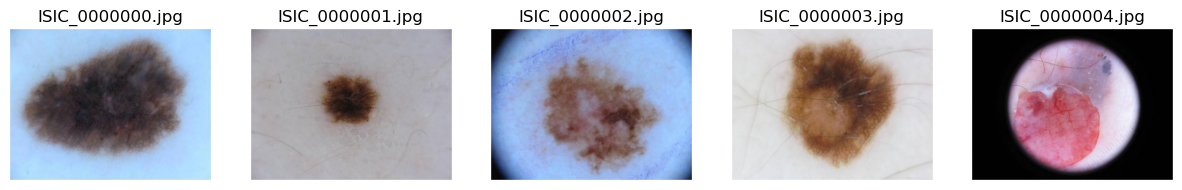

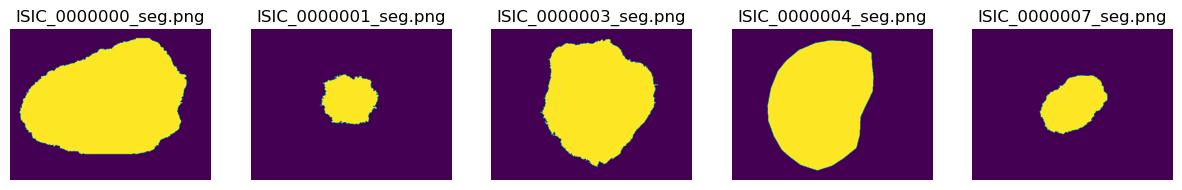

In [12]:
# Load metadata
metadata_train = pd.read_csv('metadataTrain.csv')
metadata_test = pd.read_csv('metadataTest.csv')
# Define paths
train_dir = os.path.join('Train', 'Train')  # Please change this directory if necessary
train_images = [os.path.join(train_dir, x) for x in os.listdir(train_dir) if x.endswith('.jpg')]
train_segs = [os.path.join(train_dir, x) for x in os.listdir(train_dir) if x.endswith('_seg.png')]


def display_images(images, segs=None, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i, img_path in enumerate(images[:num_images]):
        img = Image.open(img_path)
        axes[i].imshow(img)
        img_title = os.path.basename(img_path)
        axes[i].set_title(img_title)
        axes[i].axis('off')
        if segs:
            seg_path = img_path.replace('.jpg', '_seg.png')
            if os.path.exists(seg_path):
                seg = Image.open(seg_path)
                axes[i].imshow(seg, alpha=0.4)  
    plt.show()

# Display First 5 sample images
sample_images = train_images[:5]
display_images(sample_images)

# Display First 5 segmentation masks
sample_segs = train_segs[:5]
display_images(sample_segs)

In [3]:
print("Number of training images:", len(train_images))
print("Number of segmentation images:", len(train_segs))

Number of training images: 18998
Number of segmentation images: 1945


##### As we can see the number of segmentation masks is much less than the number of training images !! We have to find a solution and get the missing masks to be able to perform the feature extraction afterwards


In [4]:

print("First few rows of the data:")
print(metadata_train.head())

print("\nGeneral information about the data:")
print(metadata_train.info())

print("\nStatistical summary of numerical columns:")
print(metadata_train.describe())

# Check for any missing values
print("\nNumber of missing values in each column:")
print(metadata_train.isnull().sum())

First few rows of the data:
             ID  CLASS     SEX   AGE         POSITION
0  ISIC_0028766      2    male  30.0              NaN
1  ISIC_0071222      8    male  85.0  lower extremity
2  ISIC_0069434      3    male  85.0        head/neck
3  ISIC_0062098      1    male  55.0        head/neck
4  ISIC_0057224      8  female  45.0  lower extremity

General information about the data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18998 entries, 0 to 18997
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        18998 non-null  object 
 1   CLASS     18998 non-null  int64  
 2   SEX       18714 non-null  object 
 3   AGE       18674 non-null  float64
 4   POSITION  17028 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 742.2+ KB
None

Statistical summary of numerical columns:
              CLASS           AGE
count  18998.000000  18674.000000
mean       2.568323     53.991914
std        1.532

In [13]:
class_counts = metadata_train['CLASS'].value_counts()
print("Unique classes and their counts:")
print(class_counts)

Unique classes and their counts:
CLASS
2    9657
1    3391
3    2492
5    1968
4     650
8     471
7     190
6     179
Name: count, dtype: int64


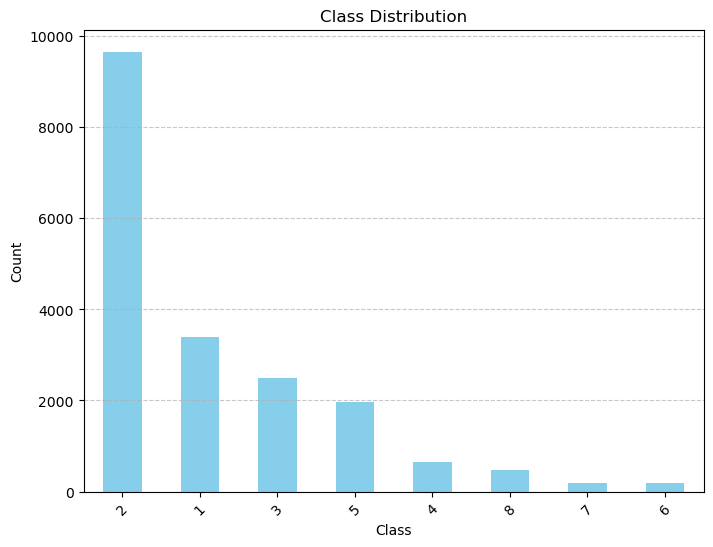

In [14]:
plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar', color='skyblue')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### We can clearly see that we have class imbalance

In [6]:
metadata_train['SEX'].fillna(metadata_train['SEX'].mode()[0], inplace=True)
metadata_train['AGE'].fillna(metadata_train['AGE'].median(), inplace=True)
metadata_train['POSITION'].fillna(metadata_train['POSITION'].mode()[0], inplace=True)

In [ ]:
train_dir = 'Train/Train'
metadata_train['image_path'] = metadata_train['ID'].apply(
    lambda id: os.path.join(train_dir, f"{id}.jpg"))
metadata_train['seg_path'] = metadata_train['ID'].apply(
    lambda id: os.path.join(train_dir, f"{id}_seg.png"))
metadata_train['image_exists'] = metadata_train['image_path'].apply(
    os.path.exists)
metadata_train['seg_exists'] = metadata_train['seg_path'].apply(os.path.exists)

metadata_train = metadata_train[metadata_train['image_exists']]

metadata_train_with_segs = metadata_train[metadata_train['seg_exists']]

train_data, val_data = train_test_split(
    metadata_train, test_size=0.2, random_state=42, stratify=metadata_train['CLASS'])

# Part 2 - Segmentation

In [4]:
def load_and_preprocess_image(path, size=(256, 256)):
    img = load_img(path, target_size=size, color_mode="rgb")
    img = img_to_array(img) / 255.0
    return img


def load_and_preprocess_mask(path, size=(256, 256)):
    mask = load_img(path, target_size=size, color_mode="grayscale")
    mask = img_to_array(mask) / 255.0
    mask = (mask > 0.5).astype(np.float32)  # Binary mask
    return mask

In [5]:
def dice_coefficient(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)


def combined_loss(y_true, y_pred):
    return 0.5 * binary_crossentropy(y_true, y_pred) + 0.5 * dice_loss(y_true, y_pred)

In [ ]:
def unet(pretrained_weights=None, input_size=(256, 256, 3), dropout_rate=0.5, l2_lambda=0.001):
    inputs = Input(input_size)
    conv1 = Conv2D(64, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(inputs)
    conv1 = Conv2D(64, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(128, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(pool1)
    conv2 = Conv2D(128, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(256, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(pool2)
    conv3 = Conv2D(256, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(512, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(pool3)
    conv4 = Conv2D(512, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(conv4)
    drop4 = Dropout(dropout_rate)(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(drop4)

    conv5 = Conv2D(1024, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(pool4)
    conv5 = Conv2D(1024, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(conv5)
    drop5 = Dropout(dropout_rate)(conv5)

    up6 = Conv2D(512, 2, activation='relu', padding='same', kernel_initializer='he_normal',
                 kernel_regularizer=l2(l2_lambda))(UpSampling2D(size=(2, 2))(drop5))
    merge6 = concatenate([drop4, up6], axis=3)
    conv6 = Conv2D(512, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(merge6)
    conv6 = Conv2D(512, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(conv6)

    up7 = Conv2D(256, 2, activation='relu', padding='same', kernel_initializer='he_normal',
                 kernel_regularizer=l2(l2_lambda))(UpSampling2D(size=(2, 2))(conv6))
    merge7 = concatenate([conv3, up7], axis=3)
    conv7 = Conv2D(256, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(merge7)
    conv7 = Conv2D(256, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(conv7)

    up8 = Conv2D(128, 2, activation='relu', padding='same', kernel_initializer='he_normal',
                 kernel_regularizer=l2(l2_lambda))(UpSampling2D(size=(2, 2))(conv7))
    merge8 = concatenate([conv2, up8], axis=3)
    conv8 = Conv2D(128, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(merge8)
    conv8 = Conv2D(128, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(conv8)

    up9 = Conv2D(64, 2, activation='relu', padding='same', kernel_initializer='he_normal',
                 kernel_regularizer=l2(l2_lambda))(UpSampling2D(size=(2, 2))(conv8))
    merge9 = concatenate([conv1, up9], axis=3)
    conv9 = Conv2D(64, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(merge9)
    conv9 = Conv2D(64, 3, activation='relu', padding='same',
                   kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(conv9)
    conv10 = Conv2D(1, 1, activation='sigmoid')(conv9)

    model = Model(inputs=inputs, outputs=conv10)
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss=combined_loss, metrics=['accuracy', dice_coefficient])

    if pretrained_weights:
        model.load_weights(pretrained_weights)

    return model

In [ ]:
data_with_masks = metadata_train[metadata_train['seg_exists']]
x = np.array([load_and_preprocess_image(path)
             for path in data_with_masks['image_path']])
y = np.array([load_and_preprocess_mask(path)
             for path in data_with_masks['seg_path']])

# Split data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, stratify=data_with_masks['CLASS'], random_state=42)

In [ ]:
class BestMetricsTracker(Callback):
    def __init__(self):
        super(BestMetricsTracker, self).__init__()
        self.best_dice = 0

    def on_epoch_end(self, epoch, logs=None):
        current_dice = logs.get('val_dice_coefficient')
        if current_dice > self.best_dice:
            self.best_dice = current_dice
            print(f"New best Dice coefficient achieved: {self.best_dice:.4f}")


model = unet() 
checkpoint = ModelCheckpoint('unet_best_model_datagen.keras', verbose=1,
                             save_best_only=True, monitor='val_dice_coefficient', mode='max')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
best_metrics_tracker = BestMetricsTracker()  

history = model.fit(
    x_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(x_val, y_val),
    callbacks=[checkpoint, early_stopping, best_metrics_tracker]
)


import json
history_dict = history.history 

with open('model_training_history.json', 'w') as file:
    json.dump(history_dict, file)


In [6]:
# custom_objects = {
#     'combined_loss': combined_loss,
#     'dice_coefficient': dice_coefficient
# }

# model = load_model('unet_best_model_gpu.keras', custom_objects=custom_objects)

In [8]:
def resize_mask(mask, original_size, extract_contour=False):
    """Resize a single mask to the original image size and optionally extract the largest contour."""
    if mask.ndim == 3 and mask.shape[-1] == 1:
        mask = mask.squeeze(-1)  

    if extract_contour:
        mask = mask > 0.5  
        mask = mask.astype(np.uint8) * 255
        contours, _ = cv2.findContours(
            mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            # Find the largest contour
            largest_contour = max(contours, key=cv2.contourArea)
            mask = np.zeros_like(mask)
            cv2.drawContours(mask, [largest_contour], -
                             1, 255, thickness=cv2.FILLED)
    else:

        mask = (mask * 255).astype(np.uint8)


    mask_image = Image.fromarray(mask, mode='L')
    resized_mask = mask_image.resize(original_size, resample=Image.NEAREST)
    return np.array(resized_mask)

def load_and_preprocess_image(path, size=(256, 256)):
    """ Load the image and resize it for prediction, also return original size. """
    img = Image.open(path)
    original_size = img.size  
    img = img.resize(size, Image.LANCZOS)
    img = np.array(img) / 255.0
    return img, original_size


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


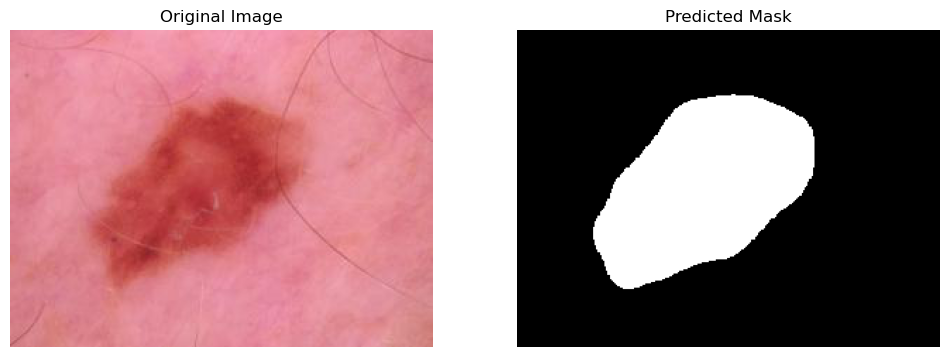

In [9]:
image_path = "Train\Train\ISIC_0026973.jpg"

# Load and preprocess the image
image, original_size = load_and_preprocess_image(image_path)
image = np.expand_dims(image, axis=0)  

# Predict mask using the model
predicted_mask = model.predict(image)
predicted_mask = predicted_mask.squeeze()  

resized_mask = resize_mask(predicted_mask > 0.5, original_size)

original_image = Image.open(image_path)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(resized_mask, cmap='gray')
plt.title("Predicted Mask")
plt.axis('off')

plt.show()


In [ ]:
def data_generator(image_paths, batch_size=32):
    total = len(image_paths)
    while True:
        for start in range(0, total, batch_size):
            end = min(start + batch_size, total)
            batch_data = [load_and_preprocess_image(
                path) for path in image_paths[start:end]]
            batch_images = np.array([data[0] for data in batch_data])
            batch_original_sizes = [data[1] for data in batch_data]
            yield batch_images, batch_original_sizes, total - end  

In [ ]:
image_paths = metadata_train[~metadata_train['seg_exists']
                             ]['image_path'].tolist()
gen = data_generator(image_paths, batch_size=32)
predicted_mask_paths = []

for x_batch, original_sizes, remaining in gen:
    batch_masks = model.predict(x_batch)
    for mask, original_size, path in zip(batch_masks, original_sizes, image_paths[len(predicted_mask_paths):]):
        resized_mask = resize_mask(mask, original_size, extract_contour=True)
        mask_path = path.replace('.jpg', '_predicted_seg.png')
        Image.fromarray(resized_mask).save(mask_path)
        predicted_mask_paths.append(mask_path)
        print(f"Processed: {path} - Remaining: {remaining}")
    if remaining == 0:
        break

for orig_path, mask_path in zip(image_paths, predicted_mask_paths):
    metadata_train.loc[metadata_train['image_path']
                       == orig_path, 'seg_path'] = mask_path
    metadata_train.loc[metadata_train['image_path']
                       == orig_path, 'seg_exists'] = True

# Part 3 - Feature Extraction

In [ ]:
def load_image_and_mask(image_path, mask_path):
    """ Load the image and its corresponding mask. """
    try:
        img = Image.open(image_path)
        img = np.array(img) / 255.0  # Normalize the image

        mask = Image.open(mask_path).convert('L')  
        mask = np.array(mask)
        mask = mask > 127 
        print(f"Loaded image and mask for {image_path}")
        return img, mask
    except Exception as e:
        print(f"Failed to load image/mask for {image_path}: {str(e)}")
        return None, None

In [ ]:
def compute_asymmetry_shape(img, mask):
    if img is None or mask is None:
        return None, None

    mask = mask.astype(bool)

    
    center_y, center_x = np.round(np.mean(np.where(mask)[0])).astype(
        int), np.round(np.mean(np.where(mask)[1])).astype(int)

    top_left = mask[:center_y, :center_x]
    top_right = mask[:center_y, center_x:]
    bottom_left = mask[center_y:, :center_x]
    bottom_right = mask[center_y:, center_x:]

    top_left, top_right = pad_to_match(top_left, top_right)
    bottom_left, bottom_right = pad_to_match(bottom_left, bottom_right)

    flipped_top_right = np.fliplr(top_right)
    flipped_bottom_right = np.fliplr(bottom_right)

    asymmetry_top = np.sum(
        np.abs(top_left.astype(int) - flipped_top_right.astype(int)))
    asymmetry_bottom = np.sum(
        np.abs(bottom_left.astype(int) - flipped_bottom_right.astype(int)))


    mask_area = np.sum(mask)
    normalized_asymmetry_top = asymmetry_top / mask_area if mask_area != 0 else 0
    normalized_asymmetry_bottom = asymmetry_bottom / \
        mask_area if mask_area != 0 else 0

    return normalized_asymmetry_top, normalized_asymmetry_bottom


def pad_to_match(a, b):
    """ Pad the smaller array among `a` and `b` to match the shape of the larger one. """
    if a.shape[0] < b.shape[0]:
        a = np.pad(a, ((0, b.shape[0] - a.shape[0]),
                   (0, 0)), mode='constant', constant_values=0)
    else:
        b = np.pad(b, ((0, a.shape[0] - b.shape[0]),
                   (0, 0)), mode='constant', constant_values=0)

    if a.shape[1] < b.shape[1]:
        a = np.pad(
            a, ((0, 0), (0, b.shape[1] - a.shape[1])), mode='constant', constant_values=0)
    else:
        b = np.pad(
            b, ((0, 0), (0, a.shape[1] - b.shape[1])), mode='constant', constant_values=0)

    return a, b

In [ ]:
def compute_features_for_dataset(metadata, image_dir):
    features = []
    for index, row in metadata.iterrows():
        image_path = os.path.join(image_dir, row['image_path'])
        print(image_path)
        mask_path = os.path.join(image_dir, row['seg_path'])

        if os.path.exists(image_path) and os.path.exists(mask_path):
            img, mask = load_image_and_mask(image_path, mask_path)
            asymmetry_top, asymmetry_bottom = compute_asymmetry_shape(
                img, mask)
            features.append((asymmetry_top, asymmetry_bottom))
        else:
            features.append((None, None))

    return features


image_dir = ''  
asymmetry_features = compute_features_for_dataset(metadata_train, image_dir)

metadata_train['asymmetry_top'] = [feat[0] for feat in asymmetry_features]
metadata_train['asymmetry_bottom'] = [feat[1] for feat in asymmetry_features]

In [2]:
def compute_color_asymmetry(img, mask):
    if not np.any(mask):
        print("Empty or invalid mask for image:")
        return None, None

    gray_img = rgb2gray(img)
    
    y_center, x_center = ndimage.center_of_mass(mask)
    if np.isnan(y_center) or np.isnan(x_center):
        print("NaN encountered in center of mass calculation for image:")
        return None, None
    
    top = gray_img[:int(y_center), :]
    bottom = gray_img[int(y_center):, :]
    left = gray_img[:, :int(x_center)]
    right = gray_img[:, int(x_center):]

    flipped_top = np.flipud(bottom) 
    flipped_right = np.fliplr(right)

    color_diff_top_bottom = np.sum(np.abs(np.histogram(top[mask[:int(y_center), :]])[0] -
                                         np.histogram(flipped_top[mask[int(y_center):, :]])[0]))
    color_diff_left_right = np.sum(np.abs(np.histogram(left[mask[:, :int(x_center)]])[0] -
                                         np.histogram(flipped_right[mask[:, int(x_center):]])[0]))

    mask_area = np.sum(mask)
    color_diff_top_bottom /= mask_area
    color_diff_left_right /= mask_area

    return color_diff_top_bottom, color_diff_left_right

In [ ]:
def add_color_asymmetry_features(metadata, image_dir):
    color_asymmetry_features = []
    for idx, row in metadata.iterrows():
        image_path = os.path.join(image_dir, row['image_path'])
        mask_path = os.path.join(image_dir, row['seg_path'])
        img, mask = load_image_and_mask(image_path, mask_path)
        if img is not None and mask is not None and np.any(mask):
            asym_top, asym_bottom = compute_color_asymmetry(img, mask)
            color_asymmetry_features.append((asym_top, asym_bottom))
        else:
            color_asymmetry_features.append((None, None))

    metadata['color_asymmetry_top'] = [feat[0]
                                       for feat in color_asymmetry_features]
    metadata['color_asymmetry_bottom'] = [feat[1]
                                          for feat in color_asymmetry_features]
    
add_color_asymmetry_features(metadata_train,image_dir)

In [ ]:
def compute_border_features(img, mask):
    if img.ndim == 3: 
        img = color.rgb2gray(img)

    dilated_mask = morphology.binary_dilation(mask, morphology.disk(1))
    eroded_mask = morphology.binary_erosion(mask, morphology.disk(1))
    border_mask = dilated_mask & ~eroded_mask

    window_size = 5 
    half_window = window_size // 2

    pixel_intensity_inside = []
    pixel_intensity_outside = []

    for y, x in np.argwhere(border_mask):
        if y < half_window or y >= img.shape[0] - half_window or x < half_window or x >= img.shape[1] - half_window:
            continue  

        local_region = img[y-half_window:y +
                        half_window+1, x-half_window:x+half_window+1]
        local_mask = mask[y-half_window:y+half_window +
                        1, x-half_window:x+half_window+1]


        intensities_inside = local_region[local_mask]
        intensities_outside = local_region[~local_mask]

        if intensities_inside.size > 0 and intensities_outside.size > 0:
            pixel_intensity_inside.extend(intensities_inside.flatten())
            pixel_intensity_outside.extend(intensities_outside.flatten())

    # Perform ANOVA 
    if pixel_intensity_inside and pixel_intensity_outside:
        f_value, p_value = stats.f_oneway(
            pixel_intensity_inside, pixel_intensity_outside)
        if np.isnan(f_value): 
            return [None, None, None]
        return [f_value, np.mean(pixel_intensity_inside), np.mean(pixel_intensity_outside)]
    else:
        return [None, None, None]

In [ ]:
def add_border_features(metadata, image_dir):
    metadata['border_f_value'] = np.nan
    metadata['border_intensity_inside'] = np.nan
    metadata['border_intensity_outside'] = np.nan

    for index, row in metadata.iterrows():
        image_path = os.path.join(image_dir, row['image_path'])
        mask_path = os.path.join(image_dir, row['seg_path'])

        img, mask = load_image_and_mask(image_path, mask_path)
        if img is not None and mask is not None:
            features = compute_border_features(img, mask)
            metadata.at[index, 'border_f_value'] = features[0]
            metadata.at[index, 'border_intensity_inside'] = features[1]
            metadata.at[index, 'border_intensity_outside'] = features[2]


add_border_features(metadata_train, image_dir)

In [ ]:
def compute_geometric_features(mask):
    props = regionprops(mask.astype(int))

    if props:
        prop = max(props, key=lambda x: x.area)
        minr, minc, maxr, maxc = prop.bbox
        width = maxc - minc
        height = maxr - minr
        area = prop.area

        equivalent_diameter = np.sqrt(4 * area / np.pi)
    else:
        minr = minc = maxr = maxc = width = height = area = equivalent_diameter = None

    return width, height, area, equivalent_diameter

In [ ]:
def add_geometric_features(metadata, image_dir):
    metadata['bounding_box_width'] = np.nan
    metadata['bounding_box_height'] = np.nan
    metadata['lesion_area'] = np.nan
    metadata['equivalent_diameter'] = np.nan

    for index, row in metadata.iterrows():
        mask_path = os.path.join(image_dir, row['seg_path'])

        if os.path.exists(mask_path):
            mask = np.array(Image.open(mask_path).convert('L'))
            mask = mask > 127 
            width, height, area, equivalent_diameter = compute_geometric_features(
                mask)

            metadata.at[index, 'bounding_box_width'] = width
            metadata.at[index, 'bounding_box_height'] = height
            metadata.at[index, 'lesion_area'] = area
            metadata.at[index, 'equivalent_diameter'] = equivalent_diameter


add_geometric_features(metadata_train, image_dir)

In [ ]:
def compute_texture_features(image, mask, settings):
    features = []
    for radius, n_points, method in settings:
        if image.ndim == 3:
            image = rgb2gray(image)  

        
        lbp = local_binary_pattern(image, n_points, radius, method)

        masked_lbp = lbp[mask > 127]

        if masked_lbp.size > 0:
            n_bins = int(masked_lbp.max() + 1)
            hist, _ = np.histogram(
                masked_lbp, bins=n_bins, range=(0, n_bins), density=True)
            percentiles = np.percentile(hist, [25, 50, 75])
            features.extend(percentiles)
        else:
            features.extend([np.nan, np.nan, np.nan])

    return features

In [ ]:
def add_lbp_features(metadata, image_dir, settings):
    num_features = 3 * len(settings)
    feature_cols = [f'lbp_feature_{i+1}' for i in range(num_features)]
    for col in feature_cols:
        metadata[col] = np.nan

    total_rows = len(metadata)
    for index, row in metadata.iterrows():
        print(f'Processing {index+1}/{total_rows} images...')
        image_path = os.path.join(image_dir, row['image_path'])
        mask_path = os.path.join(image_dir, row['seg_path'])
        if os.path.exists(image_path) and os.path.exists(mask_path):
            img = np.array(Image.open(image_path).convert('L'))
            mask = np.array(Image.open(mask_path).convert('L'))
            features = compute_texture_features(img, mask, settings)
            metadata.loc[index, feature_cols] = features

    return metadata

settings = [(1, 8, 'uniform'), (2, 16, 'uniform'), (3, 24, 'uniform')]
metadata_train_updated = add_lbp_features(
    metadata_train.copy(), image_dir, settings)

In [ ]:
def compute_fourier_features(image):
    gray_image = rgb2gray(image)
    # Compute Fourier Transform
    f_transform = fft2(gray_image)
    f_shifted = fftshift(f_transform)
    magnitude_spectrum = np.abs(f_shifted)

    mean_spectrum = np.mean(magnitude_spectrum)
    std_spectrum = np.std(magnitude_spectrum)
    return mean_spectrum, std_spectrum

In [ ]:
def add_fourier_features(metadata, image_dir):
    feature_cols = ['mean_fourier', 'std_fourier']
    for col in feature_cols:
        metadata[col] = np.nan

    total_rows = len(metadata)
    for index, row in metadata.iterrows():
        print(f'Processing {index+1}/{total_rows} images...')
        # image_path = os.path.join(image_dir, row['image_path'])
        image_path = os.path.join(image_dir, row['image_path'])
        if os.path.exists(image_path):
            img = io.imread(image_path)
            colour_features = compute_fourier_features(img)
            metadata.loc[index, feature_cols] = colour_features

    return metadata

add_fourier_features(metadata_train_updated, image_dir)

In [ ]:
def calculate_entropy(glcm):
    """Calculate entropy from GLCM."""
    with np.errstate(divide='ignore', invalid='ignore'):
        entropy = np.sum(-glcm * np.log2(glcm, where=(glcm > 0)), axis=(0, 1))
    return entropy


def compute_glc_features(image_path):
    img = io.imread(image_path)
    img_gray = color.rgb2gray(img) 
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix((img_gray * 255).astype('uint8'),
                        distances=[2], angles=angles, symmetric=True, normed=True)
    contrast = np.mean(graycoprops(glcm, 'contrast'))
    dissimilarity = np.mean(graycoprops(glcm, 'dissimilarity'))
    homogeneity = np.mean(graycoprops(glcm, 'homogeneity'))
    energy = np.mean(graycoprops(glcm, 'energy'))
    entropies = calculate_entropy(glcm)
    mean_entropy = np.mean(entropies)

    return contrast, dissimilarity, homogeneity, energy, mean_entropy


In [ ]:
def add_glc_features(metadata, image_dir):
    # feature_cols = [f'fractal_dimension{i+1}' for i in range(num_features)]
    feature_cols = ['contrast', 'dissimilarity',
                    'homogeneity', 'energy', 'mean_entropy']
    for col in feature_cols:
        metadata[col] = np.nan

    total_rows = len(metadata)
    for index, row in metadata.iterrows():
        print(f'Processing {index+1}/{total_rows} images...')
        image_path = os.path.join(image_dir, row['image_path'])
        # mask_path = os.path.join(image_dir, row['seg_path'])
        if os.path.exists(image_path):
            glc_features = compute_glc_features(image_path)
            metadata.loc[index, feature_cols] = glc_features

    return metadata

add_glc_features(metadata_train_updated, image_dir)

In [ ]:
def calculate_color_moments(image, mask):
    """
    Calculate color moments for the areas defined by the mask.

    Parameters:
    - image: numpy array of the image in RGB.
    - mask: binary numpy array where 1s indicate the region of interest.

    Returns:
    - color_features: Flattened array of color moments (mean, std, skew) for masked areas.
    """
    
    mask = mask.astype(bool)

    masked_image = image[mask]

    if masked_image.size == 0:
        return np.array([np.nan] * 9)  

    # Reshape masked_image 
    masked_image = masked_image.reshape(-1, 3)

    # Calculate mean, std, and skew for each channel in the masked region
    mean_colors = np.mean(masked_image, axis=0)
    std_colors = np.std(masked_image, axis=0)
    skew_colors = stats.skew(masked_image, axis=0)

    color_features = np.concatenate((mean_colors, std_colors, skew_colors))
    return color_features

In [ ]:
def add_color_features(metadata, image_dir):
    # feature_cols = [f'fractal_dimension{i+1}' for i in range(num_features)]
    feature_cols = ['mean_R', 'mean_G', 'mean_B', 'std_R',
                    'std_G', 'std_B', 'skew_R', 'skew_G', 'skew_B']
    for col in feature_cols:
        metadata[col] = np.nan

    total_rows = len(metadata)
    for index, row in metadata.iterrows():
        print(f'Processing {index+1}/{total_rows} images...')
        # image_path = os.path.join(image_dir, row['image_path'])
        mask_path = os.path.join(image_dir, row['seg_path'])
        image_path = os.path.join(image_dir, row['image_path'])
        if os.path.exists(mask_path):
            mask = io.imread(mask_path)
            img = io.imread(image_path)
            colour_features = calculate_color_moments(img, mask)
            metadata.loc[index, feature_cols] = colour_features

    return metadata
add_color_features(metadata_train_updated, image_dir)

In [3]:
metadata_train_updated = pd.get_dummies(
    metadata_train_updated, columns=['SEX', 'POSITION'])
metadata_train_updated = metadata_train_updated.dropna(
    subset=['bounding_box_height'])


for column in metadata_train_updated.columns:
    if metadata_train_updated[column].dtype in ['float64', 'int64']:  # Numeric columns
        mean_value = metadata_train_updated[column].mean()
        metadata_train_updated[column].fillna(mean_value, inplace=True)
features = metadata_train_updated.drop(
    ['ID', 'image_path', 'seg_path', 'image_exists', 'seg_exists', 'CLASS'], axis=1)
labels = metadata_train_updated['CLASS']

In [4]:
# Split the data with "stratify" to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, stratify=labels, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
svm_classifier = SVC(kernel='rbf', class_weight='balanced')

svm_classifier.fit(X_train_scaled, y_train)

y_pred = svm_classifier.predict(X_test_scaled)

# Evaluate the model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.56      0.58      0.57       677
           2       0.90      0.75      0.81      1929
           3       0.61      0.60      0.61       495
           4       0.30      0.59      0.40       128
           5       0.46      0.48      0.47       393
           6       0.21      0.69      0.32        36
           7       0.74      0.66      0.69        38
           8       0.26      0.51      0.34        93

    accuracy                           0.66      3789
   macro avg       0.50      0.61      0.53      3789
weighted avg       0.71      0.66      0.68      3789



In [ ]:
metadata_test = pd.read_csv('metadataTest.csv')
test_dir = os.path.join('Test', 'Test')
test_images = [os.path.join(test_dir, x)
               for x in os.listdir(test_dir) if x.endswith('.jpg')]
test_segs = [os.path.join(test_dir, x)
             for x in os.listdir(test_dir) if x.endswith('_seg.png')]

test_dir = 'Test/Test'
metadata_test['image_path'] = metadata_test['ID'].apply(
    lambda id: os.path.join(test_dir, f"{id}.jpg"))
metadata_test['seg_path'] = metadata_test['ID'].apply(
    lambda id: os.path.join(test_dir, f"{id}_seg.png"))
metadata_test['image_exists'] = metadata_test['image_path'].apply(
    os.path.exists)
metadata_test['seg_exists'] = metadata_test['seg_path'].apply(os.path.exists)

metadata_test = metadata_test[metadata_test['image_exists']]

metadata_test_with_segs = metadata_test[metadata_test['seg_exists']]
data_with_masks = metadata_test[metadata_test['seg_exists']]

def test_data_generator(image_paths, batch_size=32):
    total = len(image_paths)
    while True:
        for start in range(0, total, batch_size):
            end = min(start + batch_size, total)
            batch_data = [load_and_preprocess_image(
                path) for path in image_paths[start:end]]
            batch_images = np.array([data[0] for data in batch_data])
            batch_original_sizes = [data[1] for data in batch_data]
            yield batch_images, batch_original_sizes, total - end
            
            
test_image_paths = metadata_test[~metadata_test['seg_exists']
                                 ]['image_path'].tolist()
test_gen = test_data_generator(test_image_paths, batch_size=32)
predicted_mask_paths = []


for x_batch, original_sizes, remaining in test_gen:
    batch_masks = model.predict(x_batch)
    for mask, original_size, path in zip(batch_masks, original_sizes, test_image_paths[len(predicted_mask_paths):]):
        resized_mask = resize_mask(mask, original_size, extract_contour=True)
        mask_path = path.replace('.jpg', '_predicted_seg.png')
        Image.fromarray(resized_mask).save(mask_path)
        predicted_mask_paths.append(mask_path)
        print(f"Processed: {path} - Remaining: {remaining}")
    if remaining == 0:
        break  

# Update metadata
for orig_path, mask_path in zip(test_image_paths, predicted_mask_paths):
    metadata_test.loc[metadata_test['image_path']
                      == orig_path, 'seg_path'] = mask_path
    metadata_test.loc[metadata_test['image_path']
                      == orig_path, 'seg_exists'] = True

In [ ]:
image_dir = ''  
asymmetry_features = compute_features_for_dataset(metadata_test, image_dir)

metadata_test['asymmetry_top'] = [feat[0] for feat in asymmetry_features]
metadata_test['asymmetry_bottom'] = [feat[1] for feat in asymmetry_features]

add_color_asymmetry_features(metadata_test, image_dir)
add_border_features(metadata_test, image_dir)
add_geometric_features(metadata_test, image_dir)

settings = [(1, 8, 'uniform'), (2, 16, 'uniform'), (3, 24, 'uniform')]
metadata_test_updated = add_lbp_features(
    metadata_test.copy(), image_dir, settings)
add_glc_features(metadata_test_updated, image_dir)
add_color_features(metadata_test_updated, image_dir)
add_fourier_features(metadata_test_updated, image_dir)

In [ ]:
sample_submission = pd.read_csv('SampleSubmission.csv')

# Merge for order to be maintained
metadata_test_updated = sample_submission[['ID']].merge(
    metadata_test_updated, on='ID', how='left')
columns_to_drop = ['ID', 'image_path',
                   'seg_path', 'image_exists', 'seg_exists']
metadata_test_updated = metadata_test_updated.drop(columns=columns_to_drop)
metadata_test_updated = pd.get_dummies(
    metadata_test_updated, columns=['SEX', 'POSITION'])

mean_values = features.mean()

for col in mean_values.index:
    if col in metadata_test_updated.columns:  
        metadata_test_updated[col].fillna(mean_values[col], inplace=True)
metadata_test_scaled = pd.DataFrame(scaler.transform(
    metadata_test_updated), columns=metadata_test_updated.columns)
predictions = svm_classifier.predict(metadata_test_scaled)
sample_submission['CLASS'] = predictions

# Save the submission file
sample_submission.to_csv('final_predictions_gpu.csv', index=False)

print("Predictions have been saved to 'final_predictions_gpu.csv'.")